In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("churn_clean.csv")
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,0,0,2,1,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,3239
1,Female,No,0,1,2,1,No,Fiber optic,No,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,2701
2,Female,No,0,1,8,1,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1,5372
3,Female,No,1,1,28,1,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1,5003
4,Male,No,0,1,49,1,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1,5340


In [2]:
df['Churn Value'].value_counts(normalize=True)


Churn Value
0    0.734215
1    0.265785
Name: proportion, dtype: float64

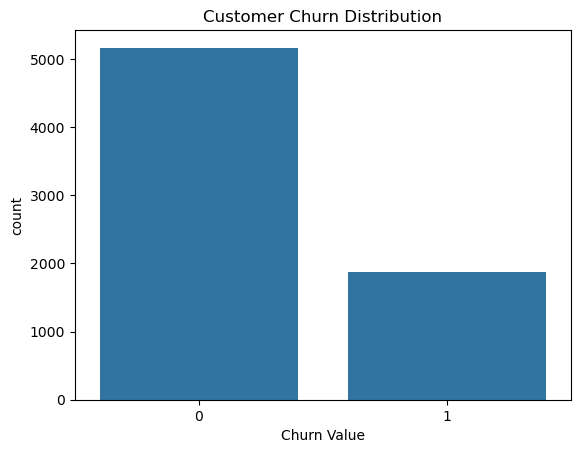

In [3]:
sns.countplot(x='Churn Value', data=df)
plt.title("Customer Churn Distribution")
plt.show()

Approximately 26.5% of customers have churned, meaning about one in four customers leaves the service. This represents a significant retention problem, and the following analysis aims to identify behavioural and service-related factors contributing to customer departure.

In [4]:
pd.crosstab(df['Contract'], df['Churn Value'], normalize='index')

Churn Value,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


Customers on month-to-month contracts show a very high churn rate (approx. 43%) compared to yearly contracts (approx. 11%) and two-year contracts (approx 3%). This indicates that lack of long-term commitment is a major driver of customer departure.

In [5]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

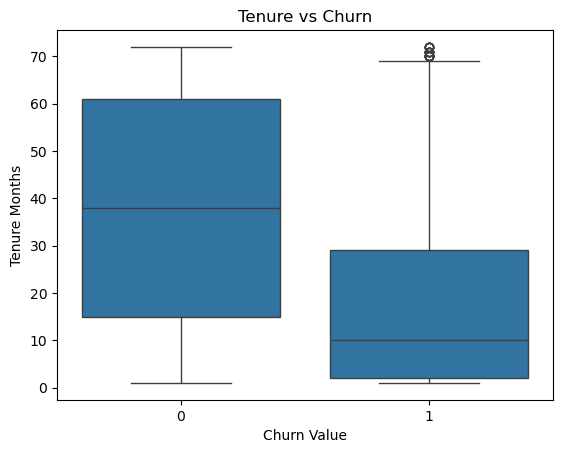

In [6]:
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)
plt.title("Tenure vs Churn")
plt.show()

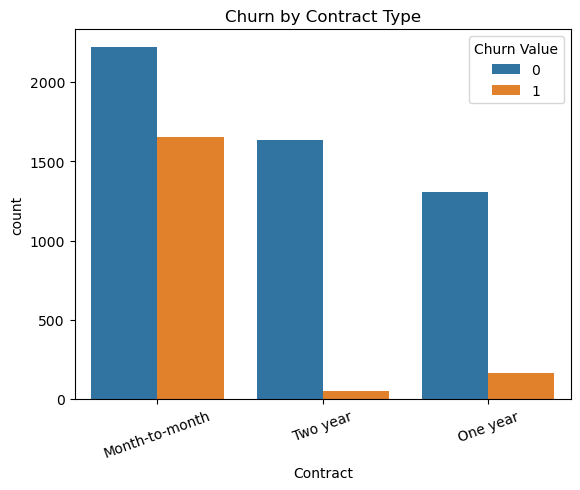

In [7]:
sns.countplot(x='Contract', hue='Churn Value', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.show()

Customer Tenure Impact

Customers who churn have significantly shorter tenure compared to retained customers. Most churn occurs within the first year of subscription, while long-term customers tend to remain with the company. This suggests early customer experience is critical for retention. This means that the company should focus more on the first 6-12 months.

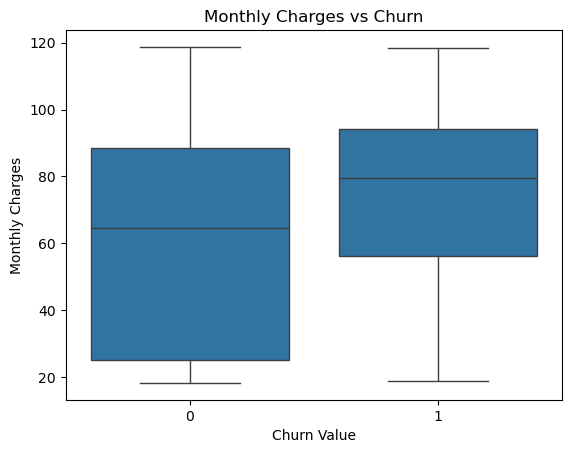

In [8]:
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Pricing Impact on Churn

Customers who churn tend to have higher monthly charges compared to retained customers. This suggests price sensitivity may contribute to churn, particularly among customers on higher-cost plans.

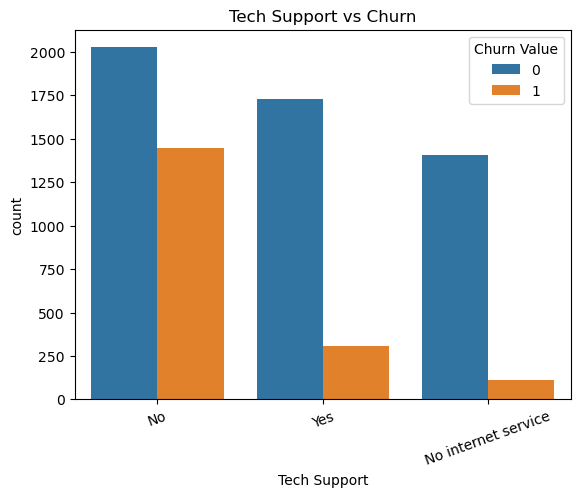

In [9]:
sns.countplot(x='Tech Support', hue='Churn Value', data=df)
plt.xticks(rotation=20)
plt.title("Tech Support vs Churn")
plt.show()

Tech Support Impact

Customers without tech support show significantly higher churn compared to those with tech support. This suggests that access to customer support services improves retention and reduces the likelihood of cancellation.

In [10]:
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 72],
    labels=['0-12 months', '12-24 months', '24+ months']
)

In [11]:
pd.crosstab(df['Tenure Group'], df['Churn Value'], normalize='index')

Churn Value,0,1
Tenure Group,,
0-12 months,0.523218,0.476782
12-24 months,0.712891,0.287109
24+ months,0.859640,0.140360


Tenure Group Impact

Customers within their first 12 months exhibit the highest churn rate (~48%), nearly half of all new customers. Churn significantly decreases as tenure increases, suggesting that early customer experience is a critical retention factor.

In [12]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['Tenure Months'] < 12) &
    (df['Tech Support'] == 'No')
]

high_risk['Churn Value'].value_counts(normalize=True)

Churn Value
1    0.616908
0    0.383092
Name: proportion, dtype: float64

DAY 4 – PART 2: Turn Insights Into Business Strategy

In [13]:
len(high_risk)

1313

In [14]:
len(high_risk) / len(df)


0.18671786120591582

Almost 1 in 5 customers are at risk of leaving the company

The identified high-risk segment consists of 1,313 customers, representing approximately 18.7% of the total customer base. Given that this segment exhibits a churn rate of over 60%, it contributes disproportionately to overall customer attrition.

In [15]:
high_risk['Monthly Charges'].mean()

np.float64(67.14935262757045)

In [16]:
len(high_risk) * high_risk['Monthly Charges'].mean()

np.float64(88167.1)

The high-risk segment generates approximately £88,000 in monthly recurring revenue, equating to over £1 million annually. Given the 62% churn rate within this group, proactive retention efforts could significantly protect revenue.